# 著者実装に対する実験

三角形の構造と直線の構造を試しに与える。

In [1]:
import os
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lingam

np.random.seed(0)

In [2]:
DATA_DIR = "dataset"
if not os.path.isdir(DATA_DIR):
    os.mkdir(DATA_DIR)

## データセット作成
三角構造と直線構造のデータセットを100個ずつ作成する。

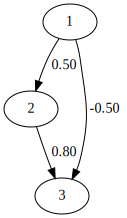

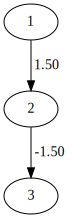

In [3]:
get_name = lambda i: f"{DATA_DIR}/data_triangle_{i:03d}.csv"
get_name2 = lambda i: f"{DATA_DIR}/data_stick_{i:03d}.csv"

for i in range(100):
    x1 = np.random.uniform(-np.sqrt(3), np.sqrt(3), size=1000)
    x2 = 0.5 * x1 + np.random.uniform(-np.sqrt(3), np.sqrt(3), size=1000)
    x3 = -0.5 * x1 + 0.8 * x2 + np.random.uniform(-np.sqrt(3), np.sqrt(3), size=1000)
    pd.DataFrame({"x1":x1,"x2":x2,"x3":x3,}).to_csv(get_name(i), index=None)

for i in range(100):
    x1 = np.random.uniform(-np.sqrt(3), np.sqrt(3), size=1000)
    x2 = 1.5 * x1 + np.random.uniform(-np.sqrt(3), np.sqrt(3), size=1000)
    x3 = -1.5 * x2 + np.random.uniform(-np.sqrt(3), np.sqrt(3), size=1000)
    pd.DataFrame({"x1":x1,"x2":x2,"x3":x3,}).to_csv(get_name2(i), index=None)

b = [
    [0, 0, 0],
    [0.5, 0, 0],
    [-0.5, 0.8, 0],
]
display(lingam.utils.make_dot(b, labels=["1","2","3"]))

b = [
    [0, 0, 0],
    [1.5, 0, 0],
    [0, -1.5, 0],
]
display(lingam.utils.make_dot(b, labels=["1","2","3"]))

## 実験
作成した100個ずつのデータセットに対してhighDLingamを適用していく。

In [4]:
r_script = """
library(highDLingam)
library(doParallel)

for (i in 0:99) {
    name <- sprintf("%s/data_triangle_%03d.csv", "./dataset", i)
    X <- read.csv(name)

    result <- findGraphMulti(as.matrix(X), degree=4)
    cat("top_order=", result$topOrder, "\n")
}

for (i in 0:99) {
    name <- sprintf("%s/data_stick_%03d.csv", "./dataset", i)
    X <- read.csv(name)

    result <- findGraphMulti(as.matrix(X), degree=4)
    cat("top_order2=", result$topOrder, "\n")
}
"""

with open("script.r", "w") as f:
    f.write(r_script)

# サブプロセスで実行して標準出力をキャプチャ
result = subprocess.run(["Rscript", "script.r"], capture_output=True)

## 結果
因果順序と出現回数を記載する。

In [5]:
# 三角構造の結果はtop_order=で始まる行に格納されている
orders = [line for line in result.stdout.decode().split("\n") if line.startswith("top_order=")]
orders = np.array([order.split("= ")[1].split(" ")[:-1] for order in orders]).astype(int)

pd.DataFrame(sorted(zip(*np.unique(orders, axis=0, return_counts=True)), key=lambda e: e[1], reverse=True), columns=["order", "num"])

,order,num
0,"[1, 2, 3]",94
1,"[1, 3, 2]",6


In [6]:
# 直線構造の結果はtop_order2=で始まる行に格納されている
orders = [line for line in result.stdout.decode().split("\n") if line.startswith("top_order2=")]
orders = np.array([order.split("= ")[1].split(" ")[:-1] for order in orders]).astype(int)

pd.DataFrame(sorted(zip(*np.unique(orders, axis=0, return_counts=True)), key=lambda e: e[1], reverse=True), columns=["order", "num"])

,order,num
0,"[1, 2, 3]",98
1,"[1, 3, 2]",2


## 仮実装

In [7]:
import itertools
import numpy as np
from sklearn.preprocessing import scale
from sklearn.utils import check_array, check_scalar
from scipy.linalg import pinvh

from lingam import DirectLiNGAM

np.random.seed(0)

class HighDimDirectLiNGAM(DirectLiNGAM):

    def __init__(self, K=4, J=3, **kwargs):
        super().__init__(**kwargs)

        self._K = check_scalar(K, "K", int, min_val=2,include_boundaries="neither")
        self._J = check_scalar(J, "J", int, min_val=1)

    def fit(self, X):
        """Fit the model to X.

        Parameters
        ----------
        X : array-like, shape (n_samples, n_features)
            Training data, where ``n_samples`` is the number of samples
            and ``n_features`` is the number of features.

        Returns
        -------
        self : object
            Returns the instance itself.
        """
        # Check parameters
        Y = check_array(X, copy=True)
        # centered
        
        n_features = Y.shape[1]

        # Causal discovery
        theta = [] 
        psi = set(range(n_features))
        # C[z][v]
        C = {}
        
        # 書き換えることのない固定値をクラスに持っておく。
        self._Y = Y
        self._alpha = 0.5
        self._sigma = np.cov(self._Y.T, bias=True)
        
        g = []
        
        for z in range(n_features):
            Cz = {}
            stats = []
            
            if z == 0:
                # XXX: z=0ではどのみち前ステップを元にした候補がないので g(0) = 0に。
                gz = 0
            else:
                r = theta[-1]
                gz = max([*g, self._alpha * self._T(r, C[z - 1][r], psi)])
            
            for v in psi:
                Cv = self._possible_parents(z, v, C, theta, psi, gz)
                stat = self._T(v, Cv, psi - set([v]))
                
                Cz[v] = Cv
                stats.append((stat, v))
            _, r = min(stats)
            theta.append(r)
            psi.remove(r)
            C[z] = Cz
            g.append(gz)
            
            # 最後は自動的に決まるので終了処理。
            if len(psi) == 1:
                theta.append(psi.pop())
                break
        
        self._causal_order = theta
        #return self._estimate_adjacency_matrix(X, prior_knowledge=self._Aknw)
        self._adjacency_matrix = np.zeros((len(Y.T), len(Y.T)))
        return self

    def _tau(self, v, u, C):
        if C is None:
            Yvi_C = self._Y[:, v]
        else:
            subcov_inv = np.linalg.pinv(self._sigma[C, :][:, C])
            Bvc = subcov_inv @ self._sigma[C, v]    
            Yvi_C = self._Y[:, v] - self._Y[:, C] @ Bvc

        # XXX: 期待値を平均値で計算
        #tau = np.mean(Yvi_C ** (self._K - 1) * self._Y[:, u]) * np.mean(Yvi_C ** 2) \
        #                        - np.mean(Yvi_C ** self._K) * np.mean(Yvi_C * self._Y[:, u])
        #tau = ((Yvi_C ** (self._K - 1) @ self._Y[:, u]) / len(self._Y)) * ((Yvi_C @ Yvi_C) / len(self._Y)) \
        #                        - ((Yvi_C ** (self._K - 1) @ Yvi_C) / len(self._Y)) * ((Yvi_C @ self._Y[:, u]) / len(self._Y))
        # 式変形版
        Yvi_C_pow = Yvi_C ** (self._K - 1)
        tau = ((Yvi_C_pow @ self._Y[:, u]) * (Yvi_C @ Yvi_C) - (Yvi_C_pow @ Yvi_C) * (Yvi_C @ self._Y[:, u])) / (len(self._Y) ** 2)
        return tau

    def _possible_parents(self, z, v, C, theta, psi, gz):
        # XXX: 前ステップのルートrを参照するが最初はないので、親候補なしとした。しきいはなし(0)でいいだろう
        if len(theta) == 0:
            return set()

        Cv = set()
        for p in C[z - 1][v]:
            # Dv
            Dv = set()
            for d in range(z):
                # XXX: Dvに空集合は入るのか？
                for i in range(1, self._J + 1):
                    comb = itertools.combinations(C[d][v] - set([p]), i)
                    Dv |= set(list(comb))

            # 判定
            taus = []
            for C_ in Dv:
                tau = self._tau(v, p, C_)
                taus.append(tau)
                
            # XXX: 条件を満たさなかったり候補なしの時はスキップ
            if len(taus) == 0 or min(taus) <= gz:
                continue
            
            Cv |= set([p])
            
        Cv |= set(theta)
        return Cv

    def _T(self, v, V1, V2, is_T1=True):
        # XXX: V1が空だと空集合の要素を探すことになってしまう。
        # XXX: そこは無視してCは空としてtauの計算はできる。
        # XXX: tauの計算時のYui.Cについて、Cが空のとき残差はデータと同一。
        if len(V1) == 0:
            # XXX: V1Jのループはない。V1Jが空集合なので消してみた。
            taus = []
            for u in V2:
                tau = self._tau(v, u, None)
                taus.append((abs(tau ** (self._K)), u))
            tau, C = max(taus)
            return tau
        
        if self._J <= len(V1):
            V1J = list(itertools.combinations(V1, self._J))
        else:
            V1J = [tuple(V1)]
        
        if is_T1:
            max_taus = []
            for C in V1J:
                taus = []
                for u in V2:
                    tau = self._tau(v, u, C)
                    tau = abs(tau ** self._K)
                    taus.append(tau)
                max_tau = max(taus)
                max_taus.append((max_tau, C))
            tau, C = min(max_taus)
        else:
            min_taus = []
            for u in V2:
                taus = []
                for C in V1J:
                    tau = self._tau(v, u, C)
                    tau = abs(tau ** self._K)
                    taus.append(tau)
                min_tau = min(taus)
                min_taus.append((min_tau, C))
            tau, C = max(min_taus)
        
        return tau

In [8]:
orders = []
for i in range(100):
    df = pd.read_csv(get_name(i))
    
    model = HighDimDirectLiNGAM()
    model.fit(df)
    
    orders.append(model.causal_order_)
pd.DataFrame(sorted(zip(*np.unique(orders, axis=0, return_counts=True)), key=lambda e: e[1], reverse=True), columns=["order", "num"])

,order,num
0,"[0, 1, 2]",100


In [9]:
orders = []
for i in range(100):
    df = pd.read_csv(get_name2(i))
    
    model = HighDimDirectLiNGAM()
    model.fit(df)
    
    orders.append(model.causal_order_)
pd.DataFrame(sorted(zip(*np.unique(orders, axis=0, return_counts=True)), key=lambda e: e[1], reverse=True), columns=["order", "num"])

,order,num
0,"[0, 1, 2]",98
1,"[0, 2, 1]",2
